# 01 — Data and Graph Construction

This notebook introduces the CTU-13 dataset and the graph construction step.
It is short and focused: load one capture, inspect the schema, split flows,
build a graph from the botnet subgraph, and visualize the giant component.

**Scenario used:** `neris_42` — a mid-sized Neris botnet capture with clear hub-and-spoke structure.

In [1]:
from pathlib import Path

import networkx as nx
import pandas as pd
import plotly.graph_objects as go

from botnet_c2.data.loader import load_capture, split_flows
from botnet_c2.graph.builder import build_flow_graph, to_simple_undirected

DATA_DIR = Path("../data")

## 1. Load

Load the `neris_42` capture. The loader validates the schema on read and
coerces `StartTime` to datetime and `TotBytes` to float64.

In [2]:
df = load_capture(DATA_DIR / "capture20110810.binetflow")

print(f"Shape:   {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
df.dtypes

Shape:   (2824636, 15)
Columns: ['StartTime', 'Dur', 'Proto', 'SrcAddr', 'Sport', 'Dir', 'DstAddr', 'Dport', 'State', 'sTos', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'Label']



StartTime    datetime64[us, UTC]
Dur                      float64
Proto                        str
SrcAddr                      str
Sport                        str
Dir                          str
DstAddr                      str
Dport                        str
State                        str
sTos                     float64
dTos                     float64
TotPkts                    int64
TotBytes                 float64
SrcBytes                   int64
Label                        str
dtype: object

In [3]:
df.head(3)

,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011-08-10 09:46:53.047277+00:00,3550.182373,udp,212.50.71.179,39678,<->,147.32.84.229,13363,CON,0.0,0.0,12,875.0,413,flow=Background-UDP-Established
1,2011-08-10 09:46:53.048843+00:00,0.000883,udp,84.13.246.132,28431,<->,147.32.84.229,13363,CON,0.0,0.0,2,135.0,75,flow=Background-UDP-Established
2,2011-08-10 09:46:53.049895+00:00,0.000326,tcp,217.163.21.35,80,<?>,147.32.86.194,2063,FA_A,0.0,0.0,2,120.0,60,flow=Background


## 2. Split

Split flows into botnet (Label contains "Botnet") and background.
Botnet flows are a small minority — this class imbalance motivates
using PR-AUC rather than accuracy as the primary evaluation metric.

In [4]:
botnet_df, background_df = split_flows(df)

total = len(df)
print(f"Total flows:      {total:>10,}")
print(f"Botnet flows:     {len(botnet_df):>10,}  ({100 * len(botnet_df) / total:.2f}%)")
print(
    f"Background flows: {len(background_df):>10,}  ({100 * len(background_df) / total:.2f}%)"
)

Total flows:       2,824,636
Botnet flows:         40,961  (1.45%)
Background flows:  2,783,675  (98.55%)


In [5]:
# Label distribution
botnet_df["Label"].value_counts().head(10)

Label
flow=From-Botnet-V42-UDP-DNS                                   26140
flow=From-Botnet-V42-TCP-Attempt-SPAM                           8105
flow=From-Botnet-V42-UDP-Attempt-DNS                            3057
flow=From-Botnet-V42-TCP-Attempt                                1881
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-63                  352
flow=From-Botnet-V42-TCP-Not-Encrypted-SMTP-Private-Proxy-1      320
flow=From-Botnet-V42-TCP-CC16-HTTP-Not-Encrypted                 221
flow=From-Botnet-V42-TCP-WEB-Established                          93
flow=From-Botnet-V42-TCP-Established-SPAM                         62
flow=From-Botnet-V42-TCP-CC53-HTTP-Not-Encrypted                  53
Name: count, dtype: int64

## 3. Build Graph

Build a directed weighted graph from the botnet flows only.
Each node is an IP address; each edge represents aggregated traffic
between two IPs, weighted by total bytes.

Construction is vectorized: `groupby` aggregation followed by
`nx.from_pandas_edgelist` — no row iteration.

In [6]:
G = build_flow_graph(botnet_df)

print(f"Nodes:   {G.number_of_nodes()}")
print(f"Edges:   {G.number_of_edges()}")
print(f"Density: {nx.density(G):.6f}")

# Giant component
wcc = list(nx.weakly_connected_components(G))
lcc_nodes = max(wcc, key=len)
print(f"\nWeakly connected components: {len(wcc)}")
print(
    f"Giant component nodes:       {len(lcc_nodes)} ({100 * len(lcc_nodes) / G.number_of_nodes():.1f}% of graph)"
)

Nodes:   4191
Edges:   4190
Density: 0.000239

Weakly connected components: 1
Giant component nodes:       4191 (100.0% of graph)


In [7]:
# Degree distribution summary
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

in_series = pd.Series(in_degrees)
out_series = pd.Series(out_degrees)

print("In-degree:")
print(in_series.describe().to_string())
print("\nOut-degree:")
print(out_series.describe().to_string())
print("\nTop 5 nodes by in-degree:")
print(in_series.nlargest(5).to_string())

In-degree:
count    4191.000000
mean        0.999761
std         0.015447
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000

Out-degree:
count    4191.000000
mean        0.999761
std        64.722486
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      4190.000000

Top 5 nodes by in-degree:
147.32.80.9       1
74.125.232.195    1
60.190.222.139    1
94.63.149.152     1
60.190.223.75     1


## 4. Visualize

Static Plotly scatter of the giant component's largest connected subgraph.
Nodes are sized by degree. The hub-and-spoke structure of C2 communication
is immediately visible: one or two high-degree hub nodes surrounded by
low-degree leaf nodes.

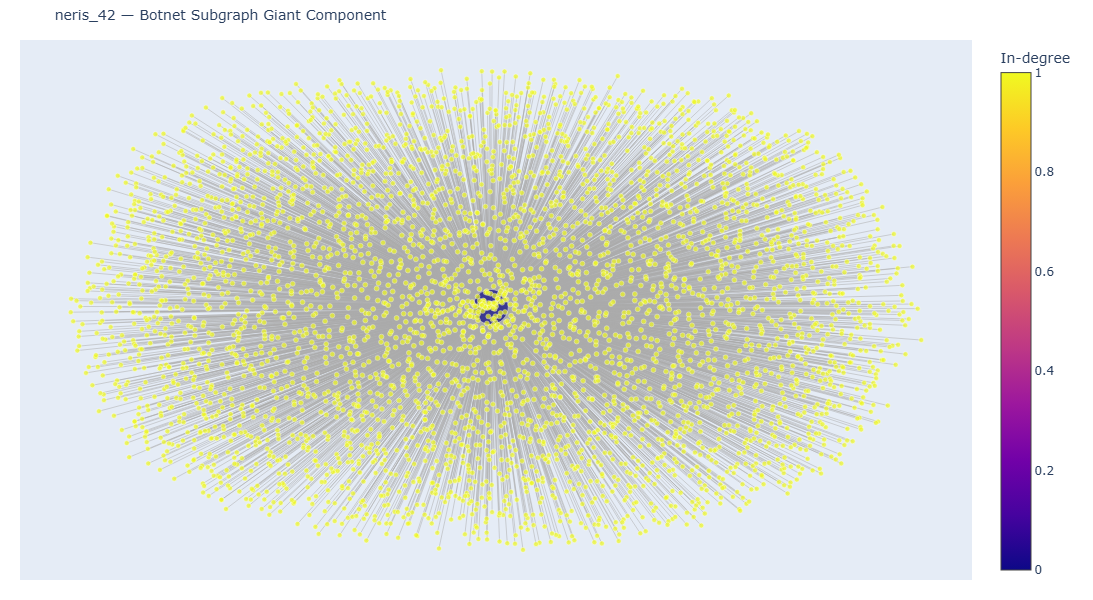

In [8]:
# Extract LCC and compute layout
lcc_directed = G.subgraph(lcc_nodes).copy()
lcc_undir = to_simple_undirected(lcc_directed)

# Spring layout — positions nodes by force-directed algorithm
# Seed for reproducibility
pos = nx.spring_layout(lcc_undir, seed=42, k=0.8)

# Node sizes proportional to degree (capped for readability)
degrees = dict(lcc_undir.degree())
max_deg = max(degrees.values())
node_sizes = [5 + 30 * (degrees[n] / max_deg) for n in lcc_undir.nodes()]

# In-degree for color (higher in-degree = more likely C2)
in_deg_lcc = dict(lcc_directed.in_degree())
node_colors = [in_deg_lcc.get(n, 0) for n in lcc_undir.nodes()]

# Build edge traces
edge_x, edge_y = [], []
for src, dst in lcc_undir.edges():
    x0, y0 = pos[src]
    x1, y1 = pos[dst]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    line=dict(width=0.5, color="#aaaaaa"),
    hoverinfo="none",
    name="edges",
)

# Build node trace
node_x = [pos[n][0] for n in lcc_undir.nodes()]
node_y = [pos[n][1] for n in lcc_undir.nodes()]
node_text = [
    f"IP: {n}<br>Degree: {degrees[n]}<br>In-degree: {in_deg_lcc.get(n, 0)}"
    for n in lcc_undir.nodes()
]

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers",
    marker=dict(
        size=node_sizes,
        color=node_colors,
        colorscale="Plasma",
        colorbar=dict(title="In-degree"),
        line=dict(width=0.5, color="white"),
    ),
    text=node_text,
    hoverinfo="text",
    name="nodes",
)

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title={"text": "neris_42 — Botnet Subgraph Giant Component", "font": {"size": 14}},
        showlegend=False,
        hovermode="closest",
        xaxis={"showgrid": False, "zeroline": False, "showticklabels": False},
        yaxis={"showgrid": False, "zeroline": False, "showticklabels": False},
        height=600,
        margin={"l": 20, "r": 20, "t": 40, "b": 20},
    ),
)
fig.show()

## 5. Bridge

The hub-and-spoke structure visible in the graph above is the topological
signature of C2 communication: infected hosts connect exclusively to the
controller, producing a star-like pattern with one high in-degree hub
surrounded by low-degree leaves.

This structure is present across all 13 CTU-13 captures. **Notebook 02**
quantifies it systematically — comparing structural metrics across all
7 botnet families to establish the analytical foundation for the ML model.